# <strong>자원 최적화</strong> AI 데이터셋

- 중소벤처기업부, Korea AI Manufacturing Platform(KAMP), 자원 최적화 AI 데이터셋, KAIST(울산과학기술원, ㈜유피시앤에스), 2021.12.27., www.kamp-ai.kr
1. <strong>분석 목적(현장 이슈, 목적)</strong>
    - 한국전력공사는 제조현장에서의 3개월 간의 최대 피크 전력을 기준으로 1년간의 전기료를 부과하고 있으며, 제조공정에서의 의도치 않은 최대 피크 전력 발생은 전기료 증가로 인한 제조비용을 증가시키는 요인으로 작용한다.
    - 따라서, 본 가이드북은 관련 데이터셋과 AI 모델을 통해 실제 제조공정에서 발생할 수 있는 최대 피크 전력을 낮추는 것을 목적으로 한다.
    - 해당 목적을 달성하기 위해 주요 변수 간의 상관관계 분석을 통해 다양한 머신러닝 방법과 알고리즘을 활용한 에너지 사용량 예측 모델을 개발하여 전력 자원 최적화를 달성한다.
<br/>
<br/> 
2. <strong>데이터셋 형태 및 수집 방법</strong>
    - <strong>분석에 사용된 변수 : </strong> 날짜, 시간, 15분, 30분, 45분, 60분, 평균, 생산량, 기온, 풍속, 습도, 강수량, 전기요금(계절), day, d, m, 공장인원, 인건비
    - <strong>데이터 수집 방법 : </strong> 공장별 변압기 감지센서를 활용한 데이터 수집 (15분 단위)
    - <strong>데이터셋 파일 확장자 : </strong> CSV
<br/>
<br/> 
3. <strong>데이터 개수 및 총량</strong>
    - <strong>데이터 개수 : </strong> 311,024개
    - <strong>데이터셋 총량 : </strong> 총 427KB
<br/>
<br/> 
4. <strong>분석 적용 알고리즘</strong>
    - <strong>알고리즘 : </strong>
      - Random Forest, Deep Neural Network
    - <strong>알고리즘 소개 : </strong>
      - Random Forest : 분류를 위한 다수의 결정 트리(Decision Tree)를 구성하고, 이를 통해 앙상블(ensemble)된 결과를 사용하는 트리 기반(가지가 뻗은 나무 모양)의 모델이다. 이런 결정 트리에서는, 트리의 깊이, 잎 개수 등의 파라미터를 조절할 수 있다. 본 가이드북에서는 제조공정에 영향을 미치는 다양한 변수들을 사용하여 전력량을 예측하는 회귀(regression) 방식의 트리들을 생성하여 전력 사용량을 예측한다.
      - Deep Neural Network : 분류를 위해 다수의 신경망을 연속적으로 쌓고, 최종적으로 각 클래스별 확률을 출력하도록 각 신경망의 모수를 업데이트하는 모델이다. 본 가이드 북에서는 연속적으로 쌓은 레이어(layer)를 통해 제조 공정 데이터에 관한 특징을 추출하고, 최종 레이어에서 전력 사용량을 예측한다.
<br/>
<br/> 
5. <strong>분석결과 및 시사점</strong>
    - 제조공정에서의 피크 전략량을 낮추기 위해 관련 생산 데이터를 수집하고, 분석하여 에너지 사용량 예측 모델을 개발하였다. 
    - 전력 사용에 영향을 미치는 생산량 등과 연계하여 제조공정 현장에서의 에너지 사용량 예측에 널리 적용될 것으로 판단된다. 

In [1]:
pip install ortools

  Using cached immutabledict-4.2.0-py3-none-any.whl.metadata (3.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 34.9 MB/s eta 0:00:00a 0:00:01
Using cached immutabledict-4.2.0-py3-none-any.whl (4.7 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.3
    Uninstalling protobuf-4.25.3:
      Successfully uninstalled protobuf-4.25.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorboard 2.17.0 requires protobuf!=4.24.0,<5.0.0,>=3.19.6, but you have protobuf 5.27.3 which is incompatible.
tensorflow 2.17.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.27.3 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [3]:
df = pd.read_csv('/mnt/datasets/21/data/okm_augumented_2021.csv')

In [4]:
df

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5


In [5]:
df.head()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


In [6]:
df.head(10)

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5
5,20210101,5,89,83,99,98,92,0,-5.5,2.1,66,0.0,109.8,5,1,1,0.0,1.5
6,20210101,6,102,111,110,103,107,0,-5.6,1.5,67,0.0,109.8,5,1,1,0.0,1.5
7,20210101,7,92,75,48,29,61,0,-6.8,0.6,73,0.0,109.8,5,1,1,0.0,1.5
8,20210101,8,27,25,22,22,24,0,-5.6,0.0,72,0.0,109.8,5,1,1,0.0,1.5
9,20210101,9,22,22,22,22,22,0,-3.3,1.2,62,0.0,109.8,5,1,1,0.0,1.0


In [7]:
df.tail()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5
6167,20210914,23,117,119,112,91,110,405,22.0,2.5,79,9.4,167.2,2,14,9,0.922551,1.5


In [8]:
df.tail(10)

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
6158,20210914,14,161,162,154,156,158,1023,21.5,2.9,92,7.2,167.2,2,14,9,1.616114,1.0
6159,20210914,15,132,169,175,168,161,1178,20.6,1.5,98,8.6,167.2,2,14,9,1.829193,1.0
6160,20210914,16,164,165,156,153,160,1395,21.7,2.5,95,9.1,167.2,2,14,9,2.186520,1.0
6161,20210914,17,117,94,133,146,123,230,21.8,2.8,91,9.1,167.2,2,14,9,0.469388,1.0
6162,20210914,18,158,164,147,163,158,973,20.9,3.5,94,9.1,167.2,2,14,9,1.539557,1.5
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5
6167,20210914,23,117,119,112,91,110,405,22.0,2.5,79,9.4,167.2,2,14,9,0.922551,1.5


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


In [10]:
df.isnull()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6164,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6165,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6166,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
df.isnull().sum()

날짜           0
시간           0
15분          0
30분          0
45분          0
60분          0
평균           0
생산량          0
기온           0
풍속           3
습도           0
강수량          1
전기요금(계절)     0
day          0
d            0
m            0
공장인원        17
인건비          0
dtype: int64

In [12]:
df['강수량'].fillna(0, inplace = True)
df

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5


In [13]:
df.fillna(0, inplace =True)
df_frame = df

In [14]:
df.isnull().sum()

날짜          0
시간          0
15분         0
30분         0
45분         0
60분         0
평균          0
생산량         0
기온          0
풍속          0
습도          0
강수량         0
전기요금(계절)    0
day         0
d           0
m           0
공장인원        0
인건비         0
dtype: int64

In [15]:
df.describe()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
count,6.168000e+03,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000
mean,2.021049e+07,12.428016,90.410182,92.695363,95.106355,95.037938,93.424125,467.344682,15.906064,2.062630,70.098735,2.243888,162.757198,4.003891,15.256809,4.770428,0.898851,1.313959
std,2.447756e+02,12.847309,55.349403,57.942122,59.285709,59.347554,57.355938,857.571815,9.160356,1.164724,22.996164,9.612754,30.820855,2.006957,8.799601,2.452431,1.983335,0.241700
min,2.021010e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-12.000000,0.000000,8.000000,0.000000,109.800000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,2.021031e+07,6.000000,23.000000,23.000000,23.000000,23.000000,23.000000,0.000000,9.600000,1.200000,53.000000,0.000000,167.200000,2.000000,8.000000,3.000000,0.000000,1.000000
50%,2.021051e+07,12.000000,101.000000,104.000000,105.000000,107.000000,104.000000,45.000000,17.400000,1.900000,74.000000,0.000000,167.200000,4.000000,15.000000,5.000000,0.111111,1.500000
75%,2.021071e+07,18.000000,133.000000,143.000000,149.000000,149.000000,144.000000,637.250000,23.300000,2.800000,91.000000,0.100000,191.600000,6.000000,23.000000,7.000000,1.160310,1.500000
max,2.021091e+07,188.000000,207.000000,222.000000,218.000000,214.000000,208.000000,9830.000000,33.400000,7.600000,98.000000,122.400000,191.600000,7.000000,31.000000,9.000000,48.386364,1.500000


In [16]:
df.corr()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
날짜,1.000000,0.065435,0.035555,0.034746,0.037285,0.036244,0.036572,0.070719,0.863028,-0.268152,0.548722,0.160855,0.835836,-0.011838,-0.035210,0.999357,-0.002136,0.005469
시간,0.065435,1.000000,0.130084,0.124554,0.115947,0.097021,0.117865,0.031816,0.150262,0.009283,-0.030201,0.049157,0.067609,-0.036188,-0.010330,0.065681,0.012563,-0.034275
15분,0.035555,0.130084,1.000000,0.980295,0.966859,0.950034,0.984688,0.520424,0.050760,0.115215,-0.085205,-0.008241,0.055881,-0.428312,0.052554,0.033601,0.295909,-0.202557
30분,0.034746,0.124554,0.980295,1.000000,0.982443,0.959004,0.991255,0.515841,0.049524,0.114173,-0.084102,-0.010410,0.056203,-0.426674,0.055754,0.032679,0.288622,-0.195760
45분,0.037285,0.115947,0.966859,0.982443,1.000000,0.984789,0.994774,0.513789,0.052818,0.115768,-0.082522,-0.013136,0.059044,-0.432957,0.056047,0.035203,0.286091,-0.211635
60분,0.036244,0.097021,0.950034,0.959004,0.984789,1.000000,0.984828,0.499723,0.055651,0.128605,-0.090875,-0.014812,0.057878,-0.437576,0.056354,0.034153,0.276778,-0.243434
평균,0.036572,0.117865,0.984688,0.991255,0.994774,0.984828,1.000000,0.517948,0.052996,0.119837,-0.086508,-0.011759,0.058096,-0.436280,0.055824,0.034499,0.289860,-0.215982
생산량,0.070719,0.031816,0.520424,0.515841,0.513789,0.499723,0.517948,1.000000,0.117780,0.115691,-0.109503,0.008171,0.068930,-0.259129,0.044836,0.068976,0.785115,-0.280625
기온,0.863028,0.150262,0.050760,0.049524,0.052818,0.055651,0.052996,0.117780,1.000000,-0.192121,0.401553,0.118524,0.809825,0.010130,0.108487,0.857490,0.030540,-0.184611
풍속,-0.268152,0.009283,0.115215,0.114173,0.115768,0.128605,0.119837,0.115691,-0.192121,1.000000,-0.440112,0.048412,-0.254750,0.004037,-0.010588,-0.267261,0.088944,-0.350115


<Axes: >

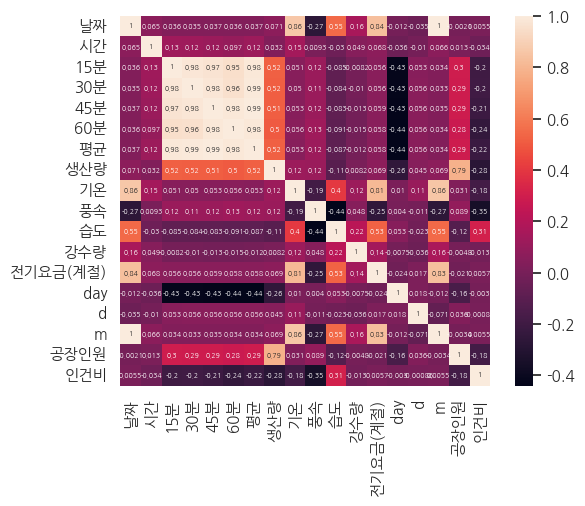

In [26]:
from matplotlib import font_manager
# 폰트 파일 경로 설정
font_path = '/mnt/datasets/21/data/NanumGothic.otf'

# 폰트 설정
font_prop = font_manager.FontProperties(fname=font_path)
font_manager.fontManager.addfont(font_path)

plt.rc('font', family=font_prop.get_name())
sns.set(font=font_prop.get_name(), 
        rc={"axes.unicode_minus": False}, 
        style="darkgrid")
sns.heatmap(df.corr(), vmax =1, square =True, annot = True, annot_kws = {'size' : 5})

In [27]:
df =df.drop(columns = ["생산량", "기온", "풍속", "습도", "강수량", "전기요금(계절)", "day", "d", "m", "공장인원", "인건비"] )
df

,날짜,시간,15분,30분,45분,60분,평균
0,20210101,0,62,61,61,61,61
1,20210101,1,96,93,116,113,105
2,20210101,2,106,96,106,107,104
3,20210101,3,92,110,110,109,105
4,20210101,4,108,105,106,108,107
...,...,...,...,...,...,...,...
6163,20210914,19,152,151,171,139,153
6164,20210914,20,124,130,128,130,128
6165,20210914,21,134,130,125,124,128
6166,20210914,22,100,109,120,114,111


In [28]:
df = df.rename(columns= {"15분" : "Peak Consumption in 15 minute",
"30분" : "Peak Consumption in 30 minute",
"45분" : "Peak Consumption in 45 minute",
"60분" : "Peak Consumption in 60 minute",
"평균" : "Average Peak Consumption in 1 hour"})

In [29]:
index_column = pd.date_range(start ='2021-01-01 00:00', end ='2021-09-14 23:00', freq ='H')
index_column

DatetimeIndex(['2021-01-01 00:00:00', '2021-01-01 01:00:00',
               '2021-01-01 02:00:00', '2021-01-01 03:00:00',
               '2021-01-01 04:00:00', '2021-01-01 05:00:00',
               '2021-01-01 06:00:00', '2021-01-01 07:00:00',
               '2021-01-01 08:00:00', '2021-01-01 09:00:00',
               ...
               '2021-09-14 14:00:00', '2021-09-14 15:00:00',
               '2021-09-14 16:00:00', '2021-09-14 17:00:00',
               '2021-09-14 18:00:00', '2021-09-14 19:00:00',
               '2021-09-14 20:00:00', '2021-09-14 21:00:00',
               '2021-09-14 22:00:00', '2021-09-14 23:00:00'],
              dtype='datetime64[ns]', length=6168, freq='H')

In [30]:
df.index = index_column
df.index.names = ['Date']
df.head()

,날짜,시간,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,,,
2021-01-01 00:00:00,20210101,0,62,61,61,61,61
2021-01-01 01:00:00,20210101,1,96,93,116,113,105
2021-01-01 02:00:00,20210101,2,106,96,106,107,104
2021-01-01 03:00:00,20210101,3,92,110,110,109,105
2021-01-01 04:00:00,20210101,4,108,105,106,108,107


In [31]:
df = df.drop(columns = ["날짜", "시간"])
df

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,
2021-01-01 00:00:00,62,61,61,61,61
2021-01-01 01:00:00,96,93,116,113,105
2021-01-01 02:00:00,106,96,106,107,104
2021-01-01 03:00:00,92,110,110,109,105
2021-01-01 04:00:00,108,105,106,108,107
...,...,...,...,...,...
2021-09-14 19:00:00,152,151,171,139,153
2021-09-14 20:00:00,124,130,128,130,128
2021-09-14 21:00:00,134,130,125,124,128


In [32]:
df['Peak Consumption in 15 minute'] = [float(str(val).replace('.','').replace(',','.')) for val in df['Peak Consumption in 15 minute'].values]
df['Peak Consumption in 30 minute'] = [float(str(val).replace('.','').replace(',','.')) for val in df['Peak Consumption in 30 minute'].values]
df['Peak Consumption in 45 minute'] = [float(str(val).replace('.','').replace(',','.')) for val in df['Peak Consumption in 45 minute'].values]
df['Peak Consumption in 60 minute'] = [float(str(val).replace('.','').replace(',','.')) for val in df['Peak Consumption in 60 minute'].values]
df.head()

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,105
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,104
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,107


In [33]:
sns.set(rc = {"figure.figsize": (20, 10)})

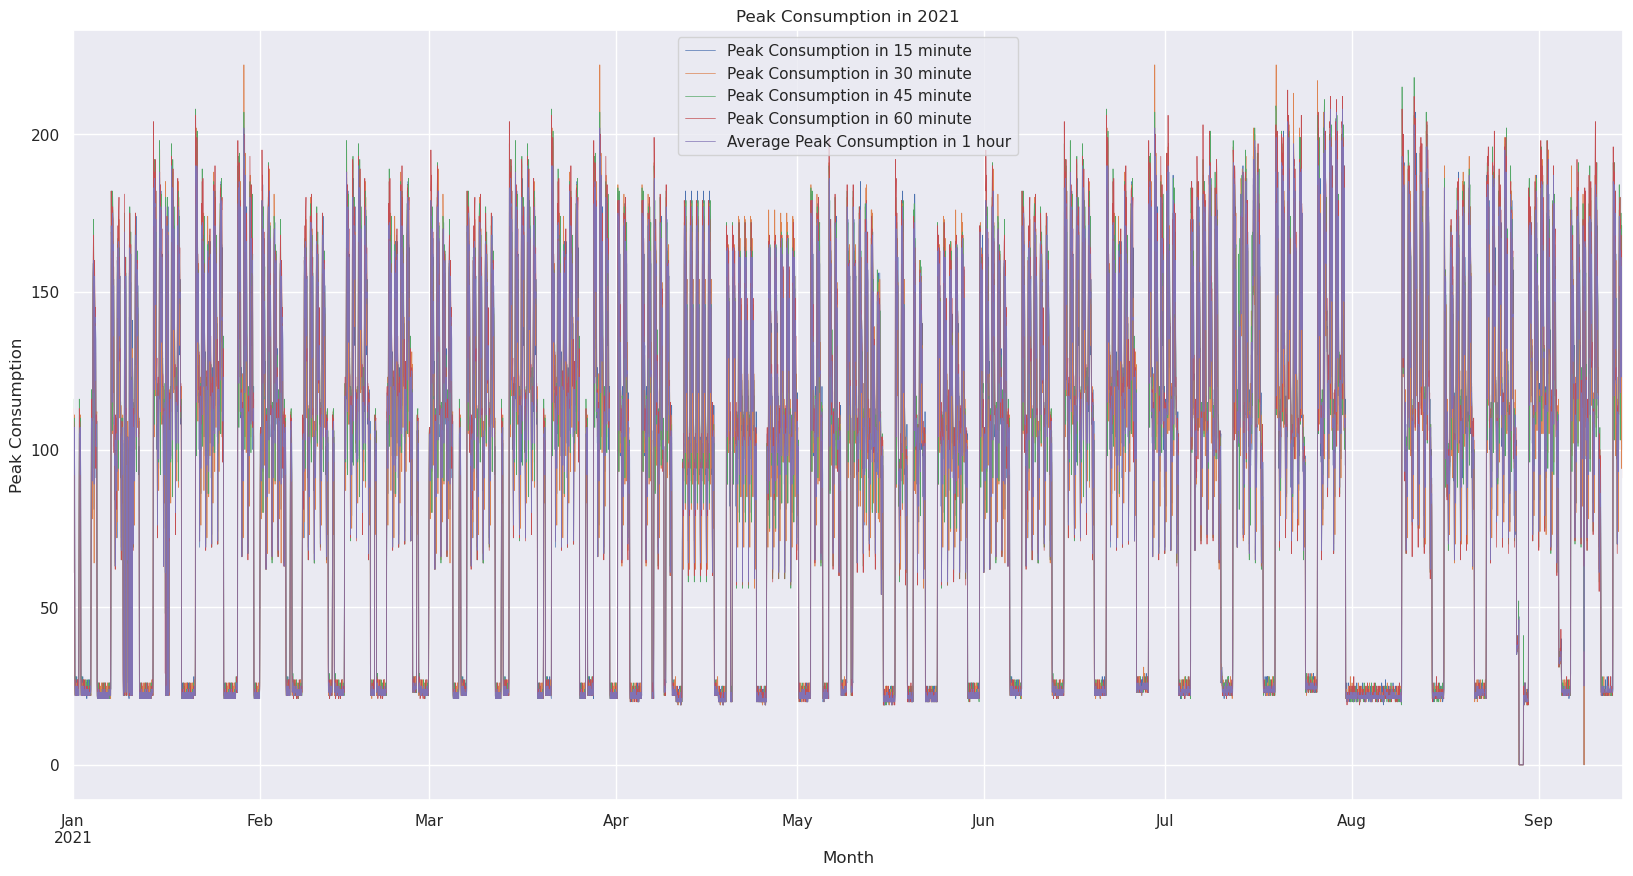

In [36]:
df.loc["2021"].plot(linewidth = 0.5)
plt.title("Peak Consumption in 2021")
plt.xlabel("Month")
plt.ylabel("Peak Consumption")
plt.show()

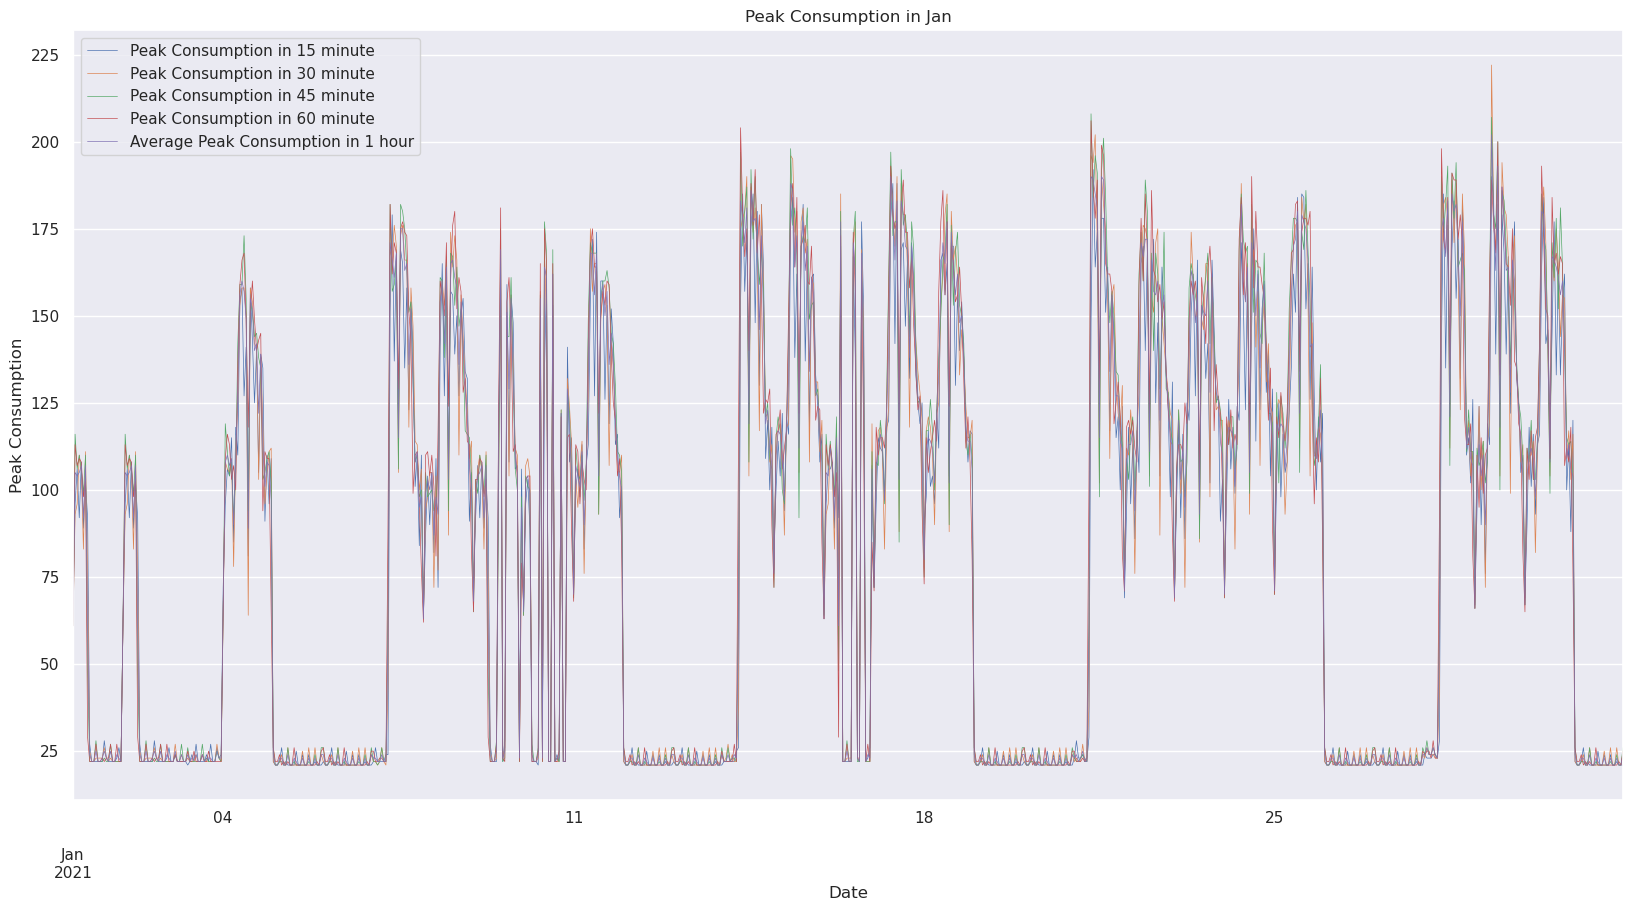

In [37]:
df.loc["2021-01"].plot(linewidth = 0.5)
plt.title("Peak Consumption in Jan")
plt.ylabel("Peak Consumption")
plt.show()

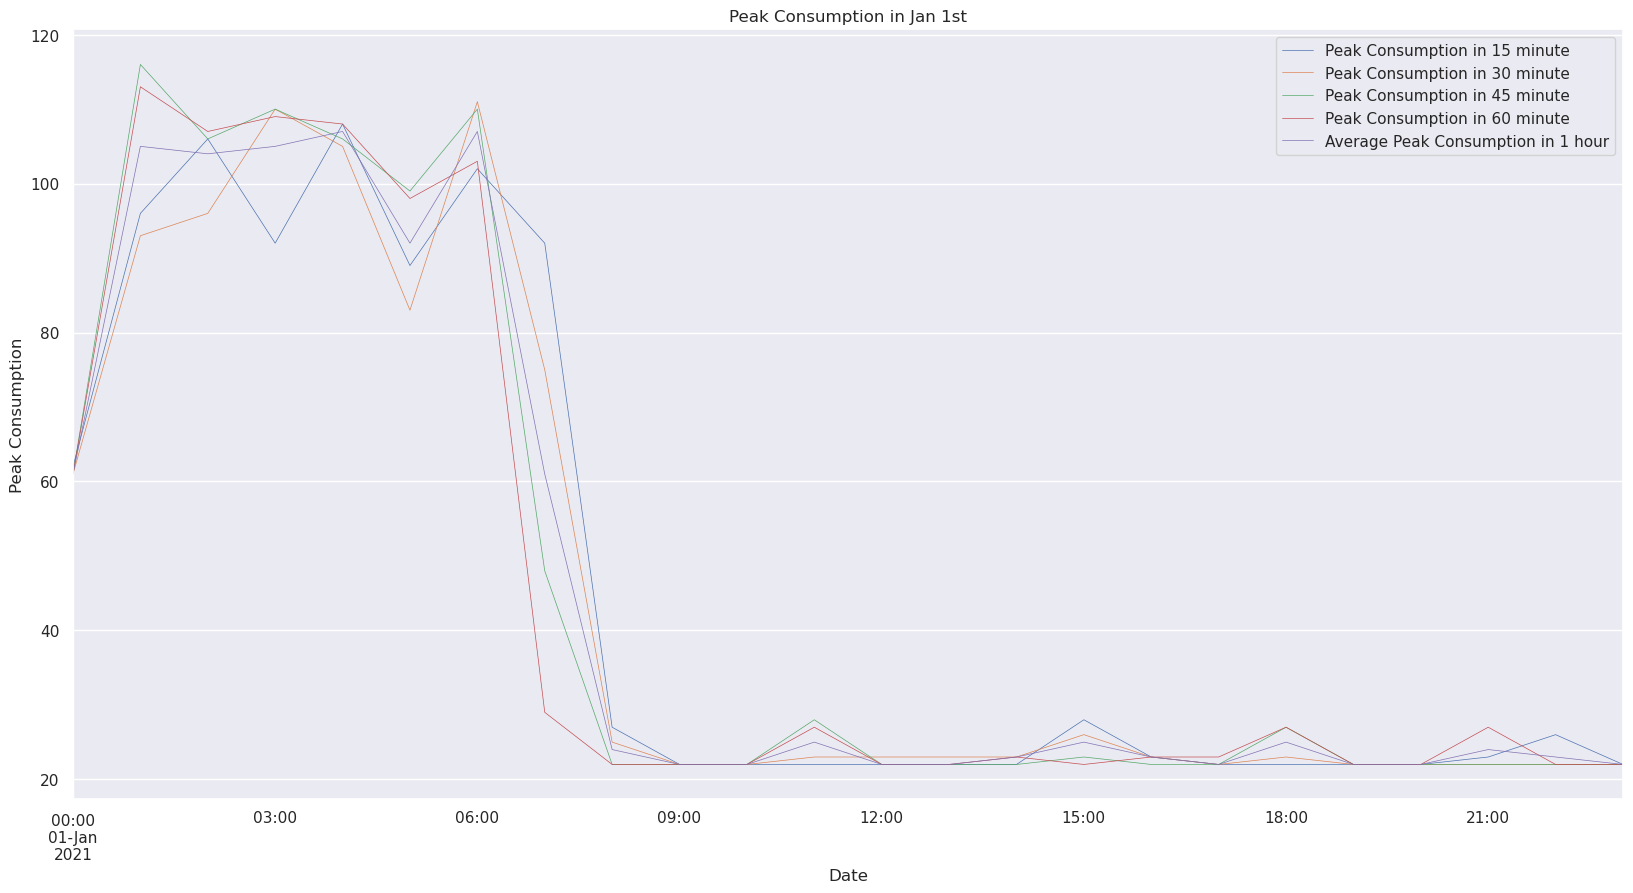

In [39]:
df.loc["2021-01-01"].plot(linewidth = 0.5)
plt.title("Peak Consumption in Jan 1st")
plt.ylabel("Peak Consumption")
plt.show()

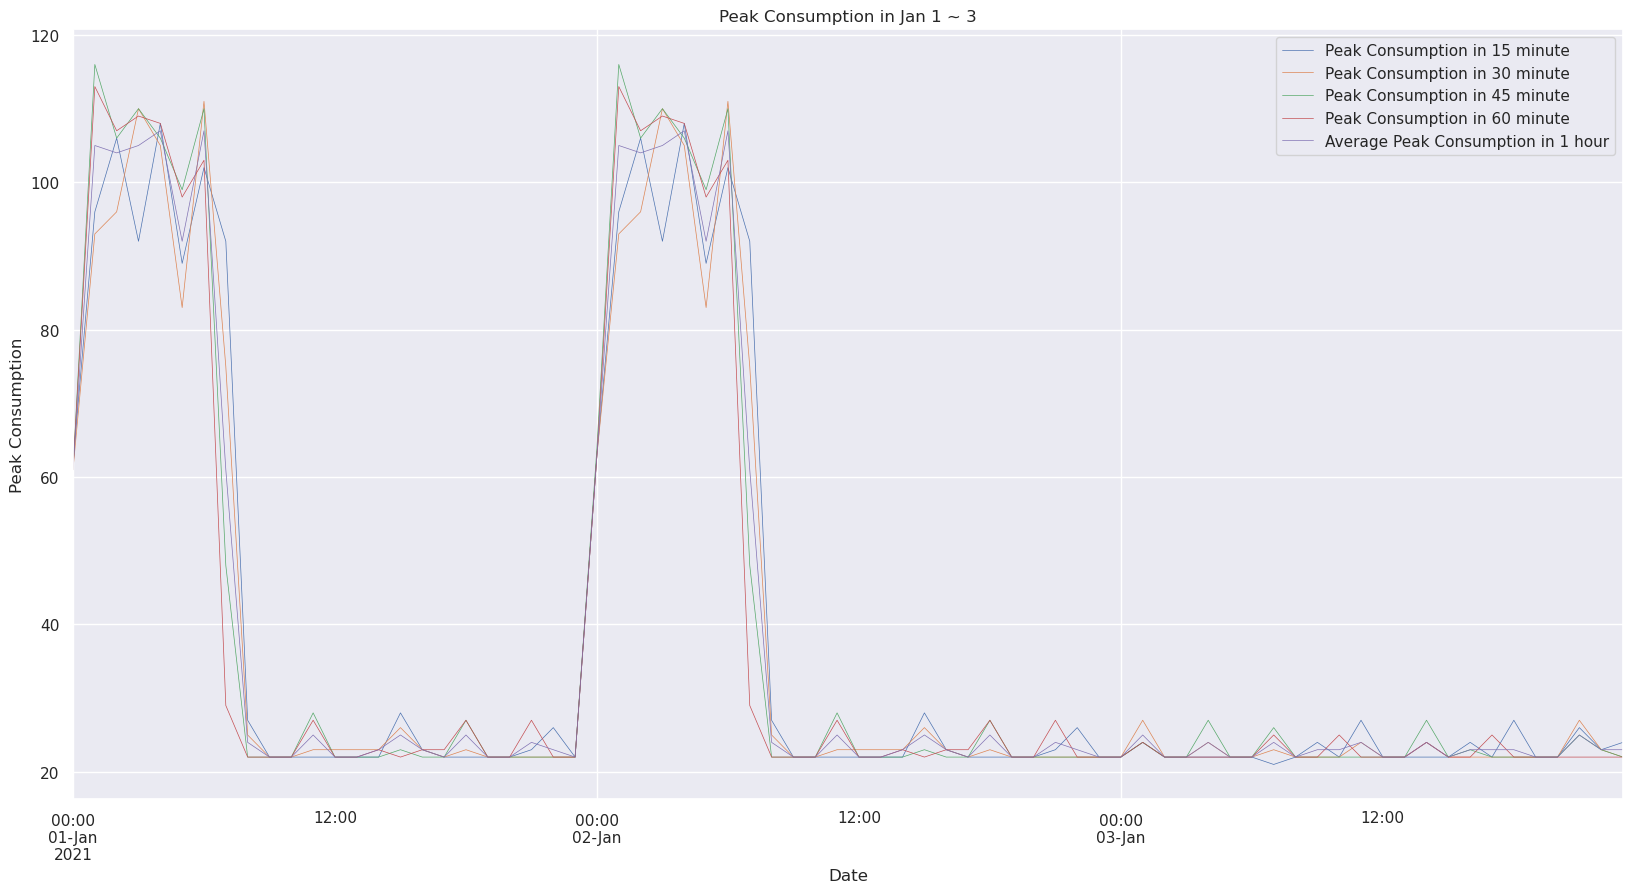

In [40]:
df.loc["2021-01-01" : "2021-01-03"].plot(linewidth = 0.5)
plt.title("Peak Consumption in Jan 1 ~ 3")
plt.ylabel("Peak Consumption")
plt.show()

In [41]:
df['Vacation'] = np.zeros(len(df))
df["Weekend"] = np.zeros(len(df))
df.head()

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61,0.0,0.0
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,105,0.0,0.0
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,104,0.0,0.0
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105,0.0,0.0
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,107,0.0,0.0


In [43]:
df.loc['2021-01-01'].index.dayofweek

Index([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype='int32', name='Date')

In [44]:
df['Weekend'][(df.index.dayofweek==5)|(df.index.dayofweek==6)] = 1
df

/tmp/ipykernel_3440/2160306251.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Weekend'][(df.index.dayofweek==5)|(df.index.dayofweek==6)] = 1


,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61,0.0,0.0
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,105,0.0,0.0
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,104,0.0,0.0
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105,0.0,0.0
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,107,0.0,0.0
...,...,...,...,...,...,...,...
2021-09-14 19:00:00,152.0,151.0,171.0,139.0,153,0.0,0.0
2021-09-14 20:00:00,124.0,130.0,128.0,130.0,128,0.0,0.0
2021-09-14 21:00:00,134.0,130.0,125.0,124.0,128,0.0,0.0


In [45]:
holidays = ["2021-01-01", "2021-02-11", "2021-02-12","2021-03-01", "2021-05-05", "2021-05-19", "2021-08-16"]

In [46]:
for gun,j in df.iterrows():
    if str(gun)[:10] in holidays:
        df["Vacation"].loc[gun] =1

/tmp/ipykernel_3440/1389387176.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Vacation"].loc[gun] =1
/tmp/ipykernel_3440/1389387176.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Vacation"].loc[gun] =1
/tmp/ipykernel_3440/1389387176.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Vacation"].loc[gun] =1
/tmp/ipykernel_3440/1389387176.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

In [47]:
df.head(5)

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61,1.0,0.0
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,105,1.0,0.0
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,104,1.0,0.0
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105,1.0,0.0
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,107,1.0,0.0


In [48]:
df.to_csv("./daily_data_seasonality.csv", index =True)

In [77]:
daily_data =pd.DataFrame(pd.read_csv("./daily_data_seasonality.csv", header =0, index_col =0, parse_dates =True)).squeeze()

In [78]:
daily_data = daily_data[["Peak Consumption in 15 minute"]]
daily_data

,Peak Consumption in 15 minute
Date,
2021-01-01 00:00:00,62.0
2021-01-01 01:00:00,96.0
2021-01-01 02:00:00,106.0
2021-01-01 03:00:00,92.0
2021-01-01 04:00:00,108.0
...,...
2021-09-14 19:00:00,152.0
2021-09-14 20:00:00,124.0
2021-09-14 21:00:00,134.0


In [79]:
n_times_advance =1
n_times_windows =168

In [80]:
# 해당 코드가 너무 오래 걸리므로 구현 방법 수정
# for k in range(n_times_advance, n_times_advance + n_times_windows):
#     daily_data["Peak Consumption in 15 minute_t-%i" % k] = np.zeros(len(daily_data["Peak Consumption in 15 minute"]))
# daily_data
# for i in range(n_times_advance + n_times_windows, len(daily_data["Peak Consumption in 15 minute"])):
#     for j in range(n_times_advance, n_times_advance + n_times_windows) :
#         daily_data["Peak Consumption in 15 minute_t-%i" % j][i] = daily_data["Peak Consumption in 15 minute"][i-j]

# 상단 코드를 수행하였으면 중복 수행할 필요는 없음
# 매번 새로 생성할 컬럼 이름 리스트
column_names = ["Peak Consumption in 15 minute_t-%i" % j for j in range(n_times_advance, n_times_advance + n_times_windows)]
# 과거 값을 가진 데이터프레임을 생성합니다
shifted_data = pd.concat([daily_data["Peak Consumption in 15 minute"].shift(j) for j in range(n_times_advance, n_times_advance + n_times_windows)], axis=1)
# 새로운 컬럼 이름을 데이터프레임에 적용합니다
shifted_data.columns = column_names
# 원래 데이터프레임과 병합합니다
daily_data = pd.concat([daily_data, shifted_data], axis=1)

In [81]:
daily_data = daily_data.iloc[n_times_advance + n_times_windows:]

In [82]:
daily_data.to_csv("./daily_data_seasonality_168.csv", index = True)
daily_data.head(3)

,Peak Consumption in 15 minute,Peak Consumption in 15 minute_t-1,Peak Consumption in 15 minute_t-2,Peak Consumption in 15 minute_t-3,Peak Consumption in 15 minute_t-4,Peak Consumption in 15 minute_t-5,Peak Consumption in 15 minute_t-6,Peak Consumption in 15 minute_t-7,Peak Consumption in 15 minute_t-8,Peak Consumption in 15 minute_t-9,...,Peak Consumption in 15 minute_t-159,Peak Consumption in 15 minute_t-160,Peak Consumption in 15 minute_t-161,Peak Consumption in 15 minute_t-162,Peak Consumption in 15 minute_t-163,Peak Consumption in 15 minute_t-164,Peak Consumption in 15 minute_t-165,Peak Consumption in 15 minute_t-166,Peak Consumption in 15 minute_t-167,Peak Consumption in 15 minute_t-168
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-08 01:00:00,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,123.0,158.0,...,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0,106.0,96.0
2021-01-08 02:00:00,104.0,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,123.0,...,22.0,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0,106.0
2021-01-08 03:00:00,90.0,104.0,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,...,22.0,22.0,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0


In [83]:
import math
from sklearn.model_selection import train_test_split

In [86]:
daily_data_168 = pd.read_csv("./daily_data_seasonality_168.csv", header=0, index_col=0, parse_dates = True).squeeze()
daily_data_168.head(3)

,Peak Consumption in 15 minute,Peak Consumption in 15 minute_t-1,Peak Consumption in 15 minute_t-2,Peak Consumption in 15 minute_t-3,Peak Consumption in 15 minute_t-4,Peak Consumption in 15 minute_t-5,Peak Consumption in 15 minute_t-6,Peak Consumption in 15 minute_t-7,Peak Consumption in 15 minute_t-8,Peak Consumption in 15 minute_t-9,...,Peak Consumption in 15 minute_t-159,Peak Consumption in 15 minute_t-160,Peak Consumption in 15 minute_t-161,Peak Consumption in 15 minute_t-162,Peak Consumption in 15 minute_t-163,Peak Consumption in 15 minute_t-164,Peak Consumption in 15 minute_t-165,Peak Consumption in 15 minute_t-166,Peak Consumption in 15 minute_t-167,Peak Consumption in 15 minute_t-168
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-08 01:00:00,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,123.0,158.0,...,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0,106.0,96.0
2021-01-08 02:00:00,104.0,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,123.0,...,22.0,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0,106.0
2021-01-08 03:00:00,90.0,104.0,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,...,22.0,22.0,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0


In [87]:
length_train_168 =len(daily_data_168) -336

In [88]:
from sklearn.preprocessing import MinMaxScaler

In [89]:
scaler_168 = MinMaxScaler(feature_range = (0,1))
scaler_168

MinMaxScaler()

In [90]:
daily_data_sc_168 = scaler_168.fit_transform(daily_data_168)
daily_data_sc_168

array([[0.42028986, 0.30917874, 0.53140097, ..., 0.44444444, 0.51207729,
        0.46376812],
       [0.50241546, 0.42028986, 0.30917874, ..., 0.52173913, 0.44444444,
        0.51207729],
       [0.43478261, 0.50241546, 0.42028986, ..., 0.42995169, 0.52173913,
        0.44444444],
       ...,
       [0.647343  , 0.59903382, 0.73429952, ..., 0.56521739, 0.50241546,
        0.64251208],
       [0.48309179, 0.647343  , 0.59903382, ..., 0.37681159, 0.56521739,
        0.50241546],
       [0.56521739, 0.48309179, 0.647343  , ..., 0.48309179, 0.37681159,
        0.56521739]])

In [91]:
data_train_168 =daily_data_sc_168[:length_train_168]

In [92]:
data_test_168 = daily_data_sc_168[-336:]

In [93]:
data_train_Y_168 = data_train_168[:,0]
data_train_X_168 = data_train_168[:,1:]
data_test_Y_168 = data_test_168[:,0]
data_test_X_168 = data_test_168[:,1:]

In [94]:
data_train_X_168 = data_train_X_168.reshape((length_train_168, 24, 7))

In [95]:
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,SimpleRNN, Flatten

2024-08-23 14:22:45.971361: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-23 14:22:45.985788: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-23 14:22:45.989934: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [96]:
model_168 = Sequential()
model_168.add(SimpleRNN(50, input_shape = (24, 7)))
model_168.add(Flatten())
model_168.add(Dense(1))
opt = tf.keras.optimizers.Adam(learning_rate = 0.0001)
model_168.compile(loss ='mean_squared_error', optimizer = opt)
model_168.fit(data_train_X_168,data_train_Y_168, epochs = 500)
model_168.summary()

I0000 00:00:1724390573.940954    3440 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1724390573.997116    3440 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1724390574.000088    3440 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1724390574.003853    3440 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Epoch 1/500


I0000 00:00:1724390576.080180    4172 service.cc:146] XLA service 0x7f20a00178d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1724390576.080237    4172 service.cc:154]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5


 42/177 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1383

I0000 00:00:1724390576.763738    4172 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,855 (34.59 KB)

 Trainable params: 2,951 (11.53 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,904 (23.07 KB)

In [97]:
preds_168 =model_168.predict(data_test_X_168.reshape((336, 24, 7)))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


In [98]:
data_predicted_168 = np.concatenate((preds_168, data_test_X_168), axis =1)
data_predicted_168

array([[0.27628037, 0.49758454, 0.52657005, ..., 0.55555556, 0.43478261,
        0.39130435],
       [0.43208352, 0.40096618, 0.49758454, ..., 0.43478261, 0.55555556,
        0.43478261],
       [0.49257889, 0.47342995, 0.40096618, ..., 0.52657005, 0.43478261,
        0.55555556],
       ...,
       [0.64653331, 0.59903382, 0.73429952, ..., 0.56521739, 0.50241546,
        0.64251208],
       [0.5017817 , 0.647343  , 0.59903382, ..., 0.37681159, 0.56521739,
        0.50241546],
       [0.53533417, 0.48309179, 0.647343  , ..., 0.48309179, 0.37681159,
        0.56521739]])

In [99]:
data_predicted_168 = scaler_168.inverse_transform(data_predicted_168)
data_predicted_168

array([[ 57.19003728, 103.        , 109.        , ..., 115.        ,
         90.        ,  81.        ],
       [ 89.44128808,  83.        , 103.        , ...,  90.        ,
        115.        ,  90.        ],
       [101.96383104,  98.        ,  83.        , ..., 109.        ,
         90.        , 115.        ],
       ...,
       [133.83239526, 124.        , 152.        , ..., 117.        ,
        104.        , 133.        ],
       [103.86881232, 134.        , 124.        , ...,  78.        ,
        117.        , 104.        ],
       [110.81417316, 100.        , 134.        , ..., 100.        ,
         78.        , 117.        ]])

In [101]:
index_column = pd.date_range(start ='2021-09-01 00:00', end ='2021-09-14 23:00',freq ='H')
best_pred_168 = pd.DataFrame(data=data_predicted_168[:,0], index=index_column)
best_pred_168.rename(columns={0 : "forecasting"}, inplace=True)
best_pred_168.to_csv("./the_best_rnn_pred_168.csv",index =True)

In [102]:
data_original =daily_data[["Peak Consumption in 15 minute"]]

In [103]:
forecast = pd.read_csv('./the_best_rnn_pred_168.csv')['forecasting']
forecast

0       57.190037
1       89.441288
2      101.963831
3       88.256960
4      107.426262
          ...    
331    157.712537
332    127.329481
333    133.832395
334    103.868812
335    110.814173
Name: forecasting, Length: 336, dtype: float64

In [104]:
compare_result = pd.DataFrame(np.array(data_original['Peak Consumption in 15 minute'][-336:]),columns=['Original 15 minute'])

In [105]:
compare_result['forecasting'] = forecast
compare_result

,Original 15 minute,forecasting
0,83.0,57.190037
1,98.0,89.441288
2,121.0,101.963831
3,90.0,88.256960
4,114.0,107.426262
...,...,...
331,152.0,157.712537
332,124.0,127.329481
333,134.0,133.832395
334,100.0,103.868812


In [106]:
index_column = pd.date_range(start ='2021-09-01 00:00', end ='2021-09-14 23:00', freq ='H')
index_column

DatetimeIndex(['2021-09-01 00:00:00', '2021-09-01 01:00:00',
               '2021-09-01 02:00:00', '2021-09-01 03:00:00',
               '2021-09-01 04:00:00', '2021-09-01 05:00:00',
               '2021-09-01 06:00:00', '2021-09-01 07:00:00',
               '2021-09-01 08:00:00', '2021-09-01 09:00:00',
               ...
               '2021-09-14 14:00:00', '2021-09-14 15:00:00',
               '2021-09-14 16:00:00', '2021-09-14 17:00:00',
               '2021-09-14 18:00:00', '2021-09-14 19:00:00',
               '2021-09-14 20:00:00', '2021-09-14 21:00:00',
               '2021-09-14 22:00:00', '2021-09-14 23:00:00'],
              dtype='datetime64[ns]', length=336, freq='H')

In [107]:
compare_result.index = index_column
compare_result.index.names = ['Date']
compare_result.head()

,Original 15 minute,forecasting
Date,,
2021-09-01 00:00:00,83.0,57.190037
2021-09-01 01:00:00,98.0,89.441288
2021-09-01 02:00:00,121.0,101.963831
2021-09-01 03:00:00,90.0,88.256960
2021-09-01 04:00:00,114.0,107.426262


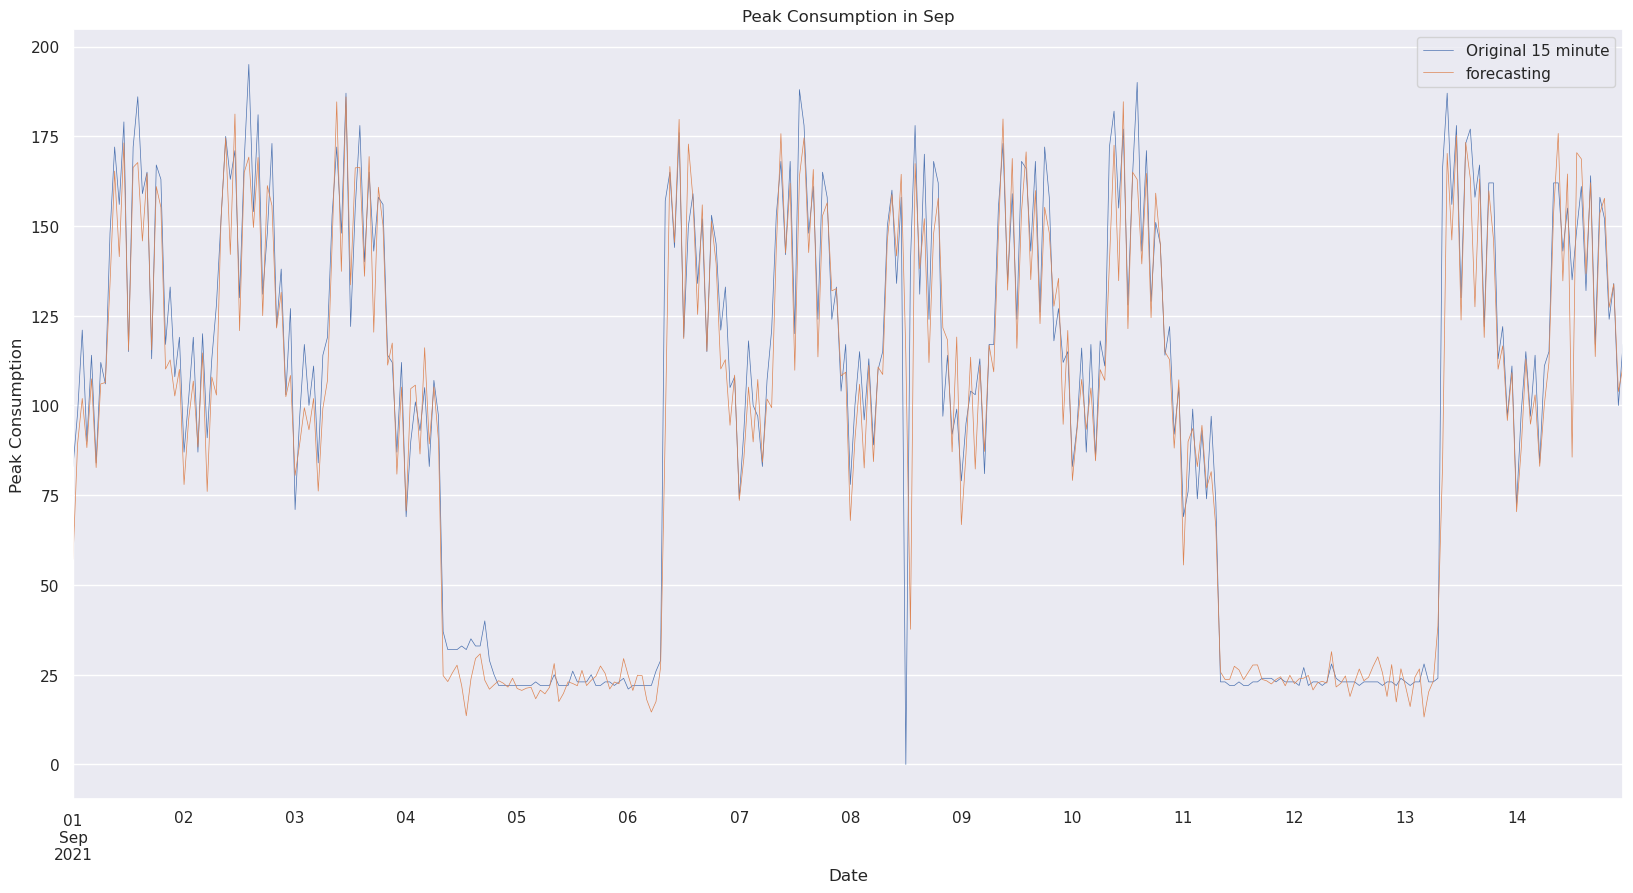

In [109]:
compare_result.loc["2021-09"].plot(linewidth =0.5)
plt.title("Peak Consumption in Sep")
plt.ylabel("Peak Consumption")
plt.show()

In [110]:
import os
import sklearn

In [111]:
df_frame

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5


In [112]:
df_frame.head()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


In [113]:
df_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6168 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6168 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6168 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


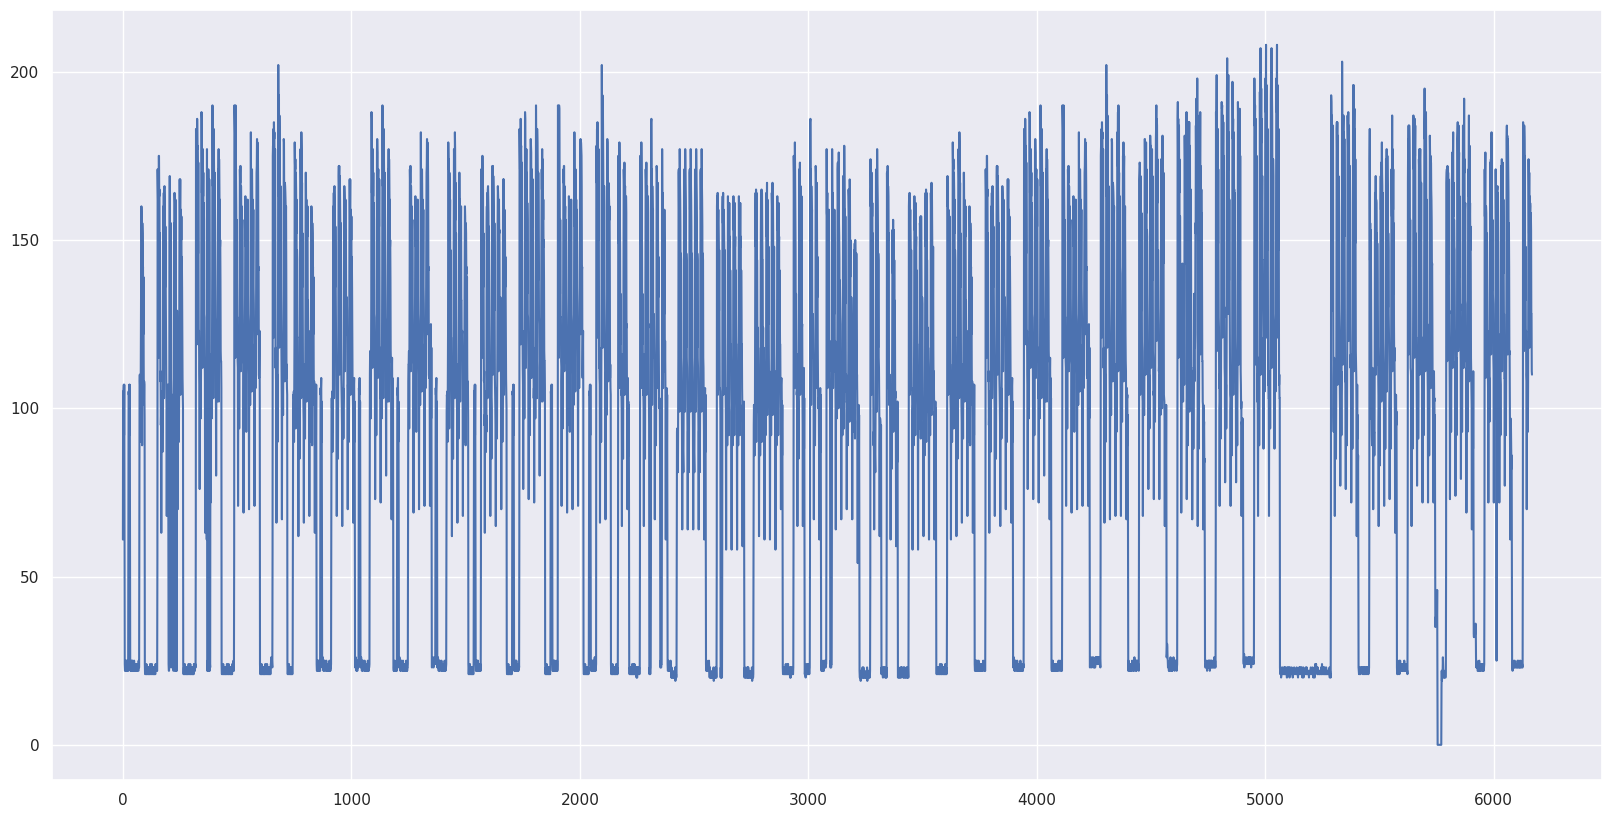

In [114]:
plt.plot(df_frame['평균'])

In [115]:
df_frame.drop(['평균', '날짜'],axis=1,inplace=True)
df_frame

,시간,15분,30분,45분,60분,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,0,62,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5
1,1,96,93,116,113,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5
2,2,106,96,106,107,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5
3,3,92,110,110,109,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5
4,4,108,105,106,108,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,19,152,151,171,139,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20,124,130,128,130,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,21,134,130,125,124,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,22,100,109,120,114,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5


In [116]:
for col in df_frame.columns:
    null_count ='column: {:>10}\t Percent of NaN value: {:.2f}%'.format(col, 100 * (df_frame[col].isnull().sum() / df_frame[col].shape[0]))
    print(null_count)

column:         시간	 Percent of NaN value: 0.00%
column:        15분	 Percent of NaN value: 0.00%
column:        30분	 Percent of NaN value: 0.00%
column:        45분	 Percent of NaN value: 0.00%
column:        60분	 Percent of NaN value: 0.00%
column:        생산량	 Percent of NaN value: 0.00%
column:         기온	 Percent of NaN value: 0.00%
column:         풍속	 Percent of NaN value: 0.00%
column:         습도	 Percent of NaN value: 0.00%
column:        강수량	 Percent of NaN value: 0.00%
column:   전기요금(계절)	 Percent of NaN value: 0.00%
column:        day	 Percent of NaN value: 0.00%
column:          d	 Percent of NaN value: 0.00%
column:          m	 Percent of NaN value: 0.00%
column:       공장인원	 Percent of NaN value: 0.00%
column:        인건비	 Percent of NaN value: 0.00%


In [117]:
label_cat_names = ['15분','30분','45분','60분']
or_cat_rm_list = ["인건비","전기요금(계절)","공장인원","생산량"]
x_train = []
cost_list = []
for index in range(0,len(df_frame)):
    for col in label_cat_names:
        temp = list(df_frame.drop(or_cat_rm_list,axis=1).drop(label_cat_names,axis=1).iloc[0])
        temp.append(df_frame[col][index])
        cost_list.append(df_frame[or_cat_rm_list].iloc[index])
        x_train.append(temp)
y_labels = []
for index in range(0,len(df_frame)):
    for col in label_cat_names:
        y_labels.append(df_frame[col][index])
y_labels.pop(0)
x_train.pop(len(x_train)-1)
cost_list.pop(len(x_train)-1)
X = np.asarray(x_train)
C = np.asarray(cost_list)
y = np.asarray(y_labels)

In [118]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.utils.random import sample_without_replacement

In [119]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)
c_train, c_test, cy_train, cy_test = train_test_split(C, y, test_size=0.3, random_state = 42)

In [120]:
forest_reg = RandomForestRegressor(max_depth=20,random_state=42)
forest_reg.fit(x_train,y_train)

RandomForestRegressor(max_depth=20, random_state=42)

In [121]:
mean_squared_error(forest_reg.predict(x_train), y_train)

185.9751419346689

In [122]:
mean_squared_error(forest_reg.predict(x_test), y_test)

183.06180686559583

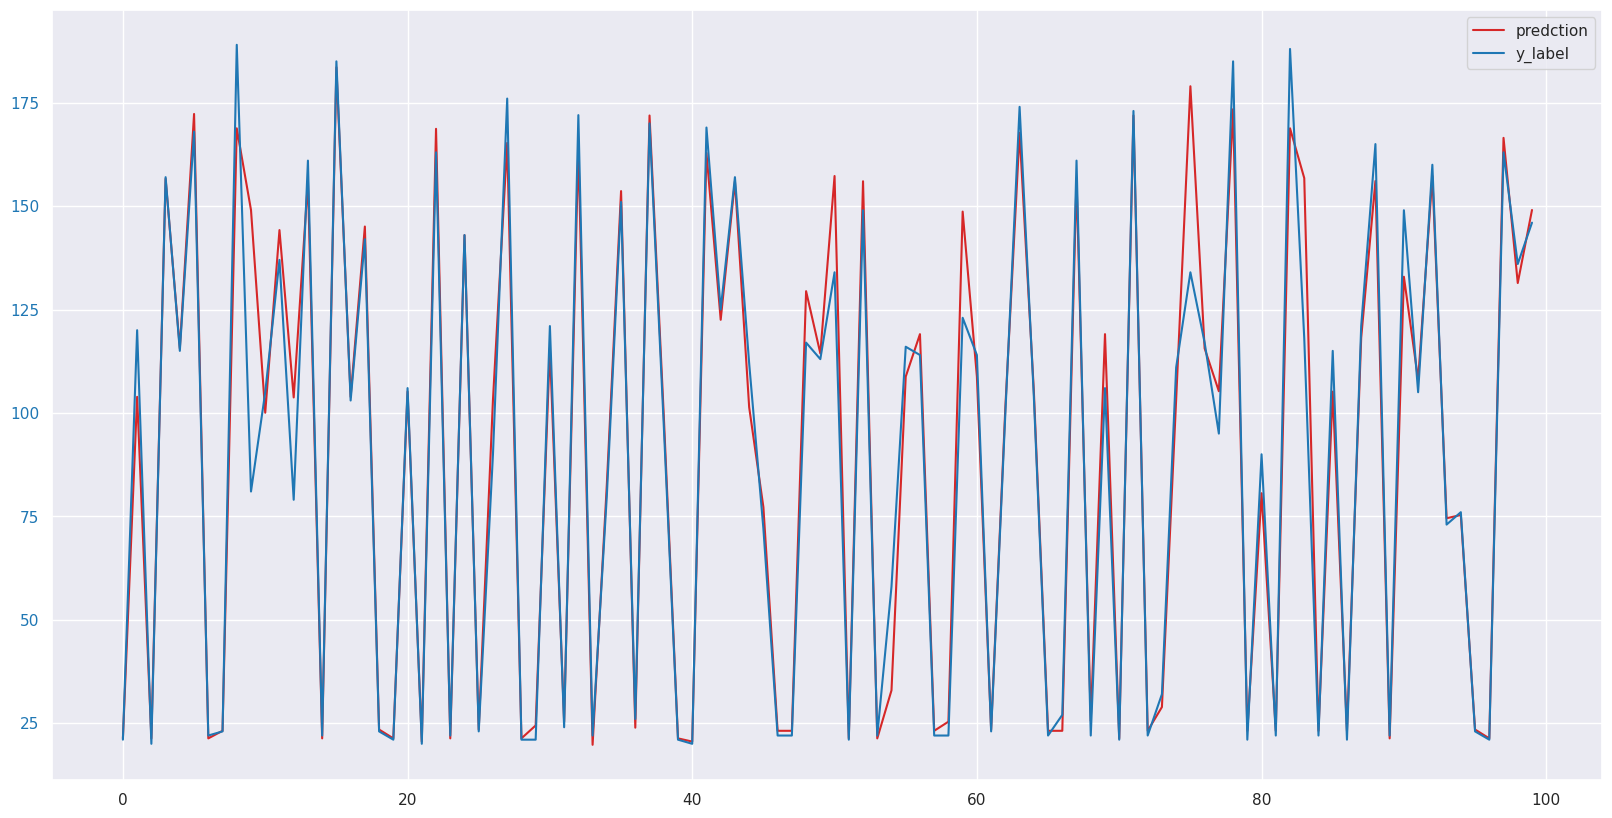

In [123]:
prediction = forest_reg.predict(x_test)
predicted_sample_indexes = sample_without_replacement(len(prediction),100)
color ='tab:red'
plt.tick_params(axis='y', labelcolor=color)
plt.plot(prediction[predicted_sample_indexes], color=color)
color ='tab:blue'
plt.plot(y_test[predicted_sample_indexes],color=color)
plt.tick_params(axis='y', labelcolor=color)
plt.legend(['predction','y_label'])
plt.show()

In [124]:
def build_objective_function_parameters(prediction,x_test, c_test, index =0):
    total_elec_price = prediction[index] * c_test[index][1] /1000 + x_test[index][-1] *1.1 - x_test[index][-2] *1.1
    total_human_cost = c_test[index][2] *50 - x_test[index][-1] *1.1 + x_test[index][-2] *1.1
    return total_elec_price,total_human_cost

In [125]:
from ortools.linear_solver import pywraplp

In [126]:
def objective_function(solver,c_test,cx,cy,x,y,index=0):
    objective = solver.Objective()
    if(c_test[index][0]==1) :
        objective.SetCoefficient(x, cx*2)
        objective.SetCoefficient(y, -cy)
    
    else:
        objective.SetCoefficient(x, cx//2)
        objective.SetCoefficient(y, -(cy)//2)
    objective.SetMinimization()
    return objective

In [127]:
def get_solution(pred,x_test,c_test,index = 118):
    solver = pywraplp.Solver.CreateSolver('GLOP')
    x = solver.NumVar(1, 2, 'x')
    y = solver.NumVar(1, 75, 'y')
    tep,thc=build_objective_function_parameters(pred,x_test, c_test, index)
    objective = objective_function(solver, c_test, tep, thc, x, y, index)
    objective = solver.Objective()
    constraint2 = solver.Constraint(11, 95)
    constraint2.SetCoefficient(x, 1)
    constraint2.SetCoefficient(y, 2)
    
    solver.Solve()
    
    opt_solution = tep * x.solution_value() - thc * y.solution_value()
    print("1이면 낮, 0이면 밤 : ", x.solution_value())
    print("공장인원 수 : ", y.solution_value())
    print("final solution: ", opt_solution)
    if x.solution_value() == 1:
        print("생산량이 ",c_test[index][-2],"일 때, 낮에 공장직원 ", y.solution_value(),"을 투입 시켜야한다.")
    else :
        print("생산량이 ",c_test[index][-2],"일 때, 밤에 공장직원 ", y.solution_value(),"을 투입 시켜야한다.")

In [128]:
c_test[111][-2]

0.171837709

In [129]:
get_solution(prediction, x_test, c_test, 111)

1이면 낮, 0이면 밤 :  1.0
공장인원 수 :  5.0
final solution:  610.4238440032458
생산량이  0.171837709 일 때, 낮에 공장직원  5.0 을 투입 시켜야한다.
